In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from dataset import CerebellumSliceDataset
from loss import CombinedLoss
from config import criterion, device, regularized_cnn, optimizer, train_dataset, train_loader, val_dataset, val_loader 

In [3]:
num_epochs = 30
best_val_dice = 0.0
smooth = 1e-6

train_loss_history = []
val_loss_history = []
val_dice_history = []
val_iou_history = []

for epoch in range(1, num_epochs + 1):
    regularized_cnn.train()
    running_train_loss = 0.0
    running_val_loss = 0.0
    
    for images, masks, patient_id, filename in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = regularized_cnn(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    avg_epoch_train_loss = running_train_loss / len(train_loader)
    
    regularized_cnn.eval()
    val_tp = 0.0
    val_fp = 0.0
    val_fn = 0.0
    
    with torch.no_grad():
        for val_images, val_masks, patient_id, filename in val_loader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            
            outputs = regularized_cnn(val_images)
            val_loss = criterion(outputs, val_masks)
            
            binary_predictions = (outputs > 0.5).float()
            binary_targets = (val_masks > 0.5).float()
            
            flat_predictions = binary_predictions.view(-1)
            flat_targets = binary_targets.view(-1)
            
            val_tp += (flat_predictions * flat_targets).sum().item()
            val_fp += (flat_predictions * (1.0 - flat_targets)).sum().item()
            val_fn += ((1.0 - flat_predictions) * flat_targets).sum().item()
            running_val_loss += val_loss.item()
    
    avg_epoch_val_loss = running_val_loss / len(val_loader)
    val_dice = (2.0 * val_tp + smooth) / (2.0 * val_tp + val_fp + val_fn + smooth)
    val_iou = (val_tp + smooth) / (val_tp + val_fp + val_fn + smooth)
    
    print(f"Epoch {epoch} | Train Loss: {avg_epoch_train_loss:.4f} | Validation Loss: {avg_epoch_val_loss:.4f} | Validation Dice: {val_dice:.4f} | Validation IoU: {val_iou:.4f}")
    
    train_loss_history.append(avg_epoch_train_loss)
    val_loss_history.append(avg_epoch_val_loss)
    val_dice_history.append(val_dice)
    val_iou_history.append(val_iou)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(regularized_cnn.state_dict(), "best_regularized_model.pth")
        print("Checkpoint saved message")

Epoch 1 | Train Loss: 0.5875 | Validation Loss: 0.4532 | Validation Dice: 0.7782 | Validation IoU: 0.6369
Checkpoint saved message
Epoch 2 | Train Loss: 0.4377 | Validation Loss: 0.4267 | Validation Dice: 0.7271 | Validation IoU: 0.5712
Epoch 3 | Train Loss: 0.4132 | Validation Loss: 0.4061 | Validation Dice: 0.8280 | Validation IoU: 0.7065
Checkpoint saved message
Epoch 4 | Train Loss: 0.4050 | Validation Loss: 0.3958 | Validation Dice: 0.8814 | Validation IoU: 0.7880
Checkpoint saved message
Epoch 5 | Train Loss: 0.3987 | Validation Loss: 0.3914 | Validation Dice: 0.9106 | Validation IoU: 0.8359
Checkpoint saved message
Epoch 6 | Train Loss: 0.3940 | Validation Loss: 0.3898 | Validation Dice: 0.9317 | Validation IoU: 0.8721
Checkpoint saved message
Epoch 7 | Train Loss: 0.3929 | Validation Loss: 0.3953 | Validation Dice: 0.8887 | Validation IoU: 0.7996
Epoch 8 | Train Loss: 0.3927 | Validation Loss: 0.3874 | Validation Dice: 0.9234 | Validation IoU: 0.8578
Epoch 9 | Train Loss: 0.389

In [4]:
import matplotlib.pyplot as plt

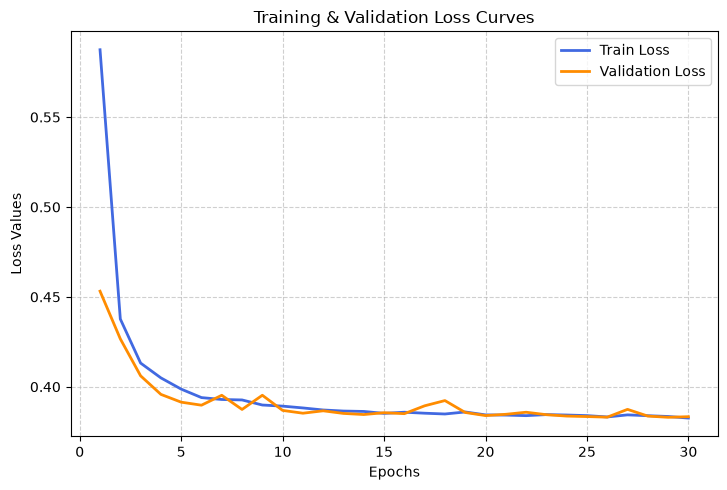

In [5]:
epochs = list(range(1, num_epochs + 1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(epochs, train_loss_history, label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(epochs, val_loss_history, label="Validation Loss", color="darkorange", linewidth=2)

ax[0].set_title("Training & Validation Loss Curves")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss Values")
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].set_visible(False)

plt.tight_layout()
plt.show()

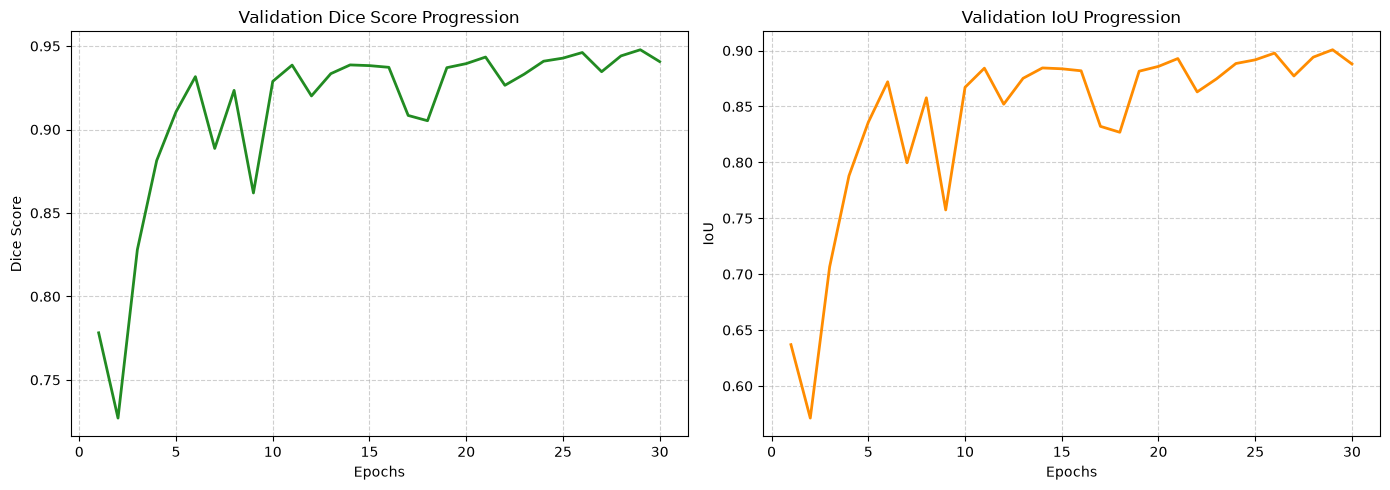

In [6]:
fig, new_ax = plt.subplots(1, 2, figsize=(14, 5))

new_ax[0].plot(epochs, val_dice_history, label="Validation Dice Score", color="forestgreen", linewidth=2)
new_ax[0].set_title("Validation Dice Score Progression")
new_ax[0].set_xlabel("Epochs")
new_ax[0].set_ylabel("Dice Score")
new_ax[0].grid(True, linestyle="--", alpha=0.6)


new_ax[1].plot(epochs, val_iou_history, label="Validation IoU", color="darkorange", linewidth=2)
new_ax[1].set_title("Validation IoU Progression")
new_ax[1].set_xlabel("Epochs")
new_ax[1].set_ylabel("IoU")
new_ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()